In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
df = pd.read_csv('../data/processed/unemployment_clean.csv', parse_dates=['Date'])

print(df.columns.tolist())
print(df.shape)
print(df.dtypes)

['Region', 'Date', 'Estimated_Unemployment_Rate_(%)', 'Estimated_Employed', 'Estimated_Labour_Participation_Rate_(%)', 'Area']
(740, 6)
Region                                                str
Date                                       datetime64[us]
Estimated_Unemployment_Rate_(%)                   float64
Estimated_Employed                                float64
Estimated_Labour_Participation_Rate_(%)           float64
Area                                                  str
dtype: object


In [49]:
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.month_name()

df[['Month', 'Month_Name', 'Date']].head(15)

,Month,Month_Name,Date
0,5,May,2019-05-31
1,6,June,2019-06-30
2,7,July,2019-07-31
3,8,August,2019-08-31
4,9,September,2019-09-30
5,10,October,2019-10-31
6,11,November,2019-11-30
7,12,December,2019-12-31
8,1,January,2020-01-31
9,2,February,2020-02-29


### A heads-up before we look at monthly averages

We only have about 14 months of data (May 2019 to June 2020). Most calendar
months (like April) show up only ONCE in that whole stretch. Only May and June
show up twice.

This matters a lot: April 2020 was the worst month of COVID lockdown. So if we
average "April" across our data, we're not getting a real seasonal average —
we're just getting that one bad April, dressed up to look like a repeating
pattern. Keep this in mind for the next chart.

In [50]:
monthly_avg = (
    df.groupby(['Month', 'Month_Name'])['Estimated_Unemployment_Rate_(%)']
    .mean()
    .reset_index()
    .sort_values('Month')
)

monthly_avg



,Month,Month_Name,Estimated_Unemployment_Rate_(%)
0,1,January,9.950755
1,2,February,9.964717
2,3,March,10.700577
3,4,April,23.641569
4,5,May,16.646190
5,6,June,10.553462
6,7,July,9.033889
7,8,August,9.637925
8,9,September,9.051731
9,10,October,9.900909


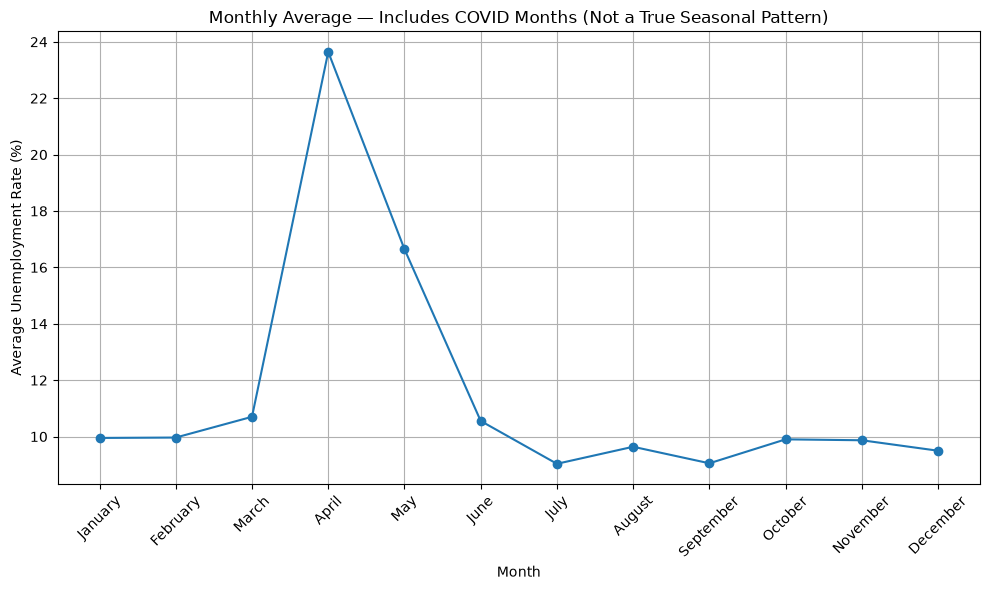

In [51]:
plt.figure(figsize=(10, 6))

plt.plot(
    monthly_avg['Month_Name'],
    monthly_avg['Estimated_Unemployment_Rate_(%)'],
    marker='o'
)

plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('Average Unemployment Rate (%)')
plt.title('Monthly Average — Includes COVID Months (Not a True Seasonal Pattern)')
plt.grid(True)

plt.tight_layout()
plt.savefig('../images/11_unemployment_rate_per_month.png', dpi=150, bbox_inches='tight')
plt.show()

### What this chart actually shows

The April and May spikes here are NOT a normal seasonal pattern. They're the
COVID lockdown — since April and May 2020 are the only April and May we have
in this whole dataset, this chart can't tell the difference between "COVID
happened" and "this is what April is always like." Don't trust this chart for
seasonality. The next section fixes this by looking at the months before
COVID only.

### Looking at months before COVID only

To get a fairer look at normal month-to-month movement, we'll only use data
from before lockdown started (before March 2020). This removes the COVID
spike from the picture.

One honest limit to keep in mind: even this "before COVID" stretch is only
about 10 months, and none of those months repeat either. So this still isn't
proof of a repeating yearly pattern — it's just a clean look at what actually
happened, month by month, before COVID hit.

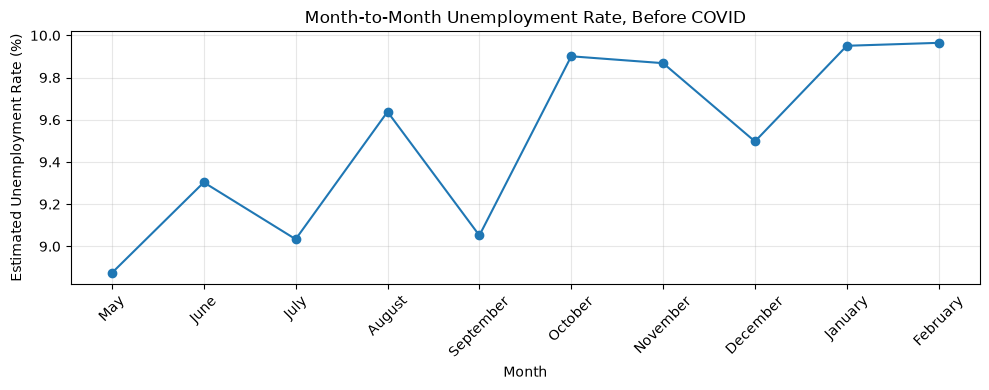

In [55]:
pre_covid = df[df['Date'] < '2020-03-01']

pre_covid_avg = (
    pre_covid
    .groupby(['Month', 'Month_Name'])['Estimated_Unemployment_Rate_(%)']
    .mean()
    .reset_index()
)

# Sort by the real order months happened in, not by calendar month number
month_time_order = pre_covid.drop_duplicates('Month_Name').sort_values('Date')['Month_Name'].tolist()
pre_covid_avg['Month_Name'] = pd.Categorical(pre_covid_avg['Month_Name'], categories=month_time_order, ordered=True)
pre_covid_avg = pre_covid_avg.sort_values('Month_Name')

plt.figure(figsize=(10, 4))

plt.plot(
    pre_covid_avg['Month_Name'],
    pre_covid_avg['Estimated_Unemployment_Rate_(%)'],
    marker='o'
)

plt.title('Month-to-Month Unemployment Rate, Before COVID')
plt.xlabel('Month')
plt.ylabel('Estimated Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../images/12_pre_covid_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()


### What we see before COVID

Before lockdown, the unemployment rate moved a little from month to month, but
stayed mostly steady (roughly 9-10%, based on earlier EDA). No dramatic swings.
This is our best honest picture of "normal" — and it's very different from the
huge spike we saw once COVID hit.

### Looking at this by region

Now let's check whether all regions move together the same way, or if some
regions behave differently month to month. Since we have 28 regions, a normal
line chart (one line per region) would be way too messy to read — 28
overlapping lines and a giant legend. Instead, we'll use a heatmap: regions
down the side, months across the top, and color showing the rate. Much easier
to spot patterns.

One more honest note: for most months, each region only has ONE data point
(same reason as before — not enough years of data). Only May and June have two
years to actually average together. So most of this heatmap is showing "what
happened," not "the average over time."

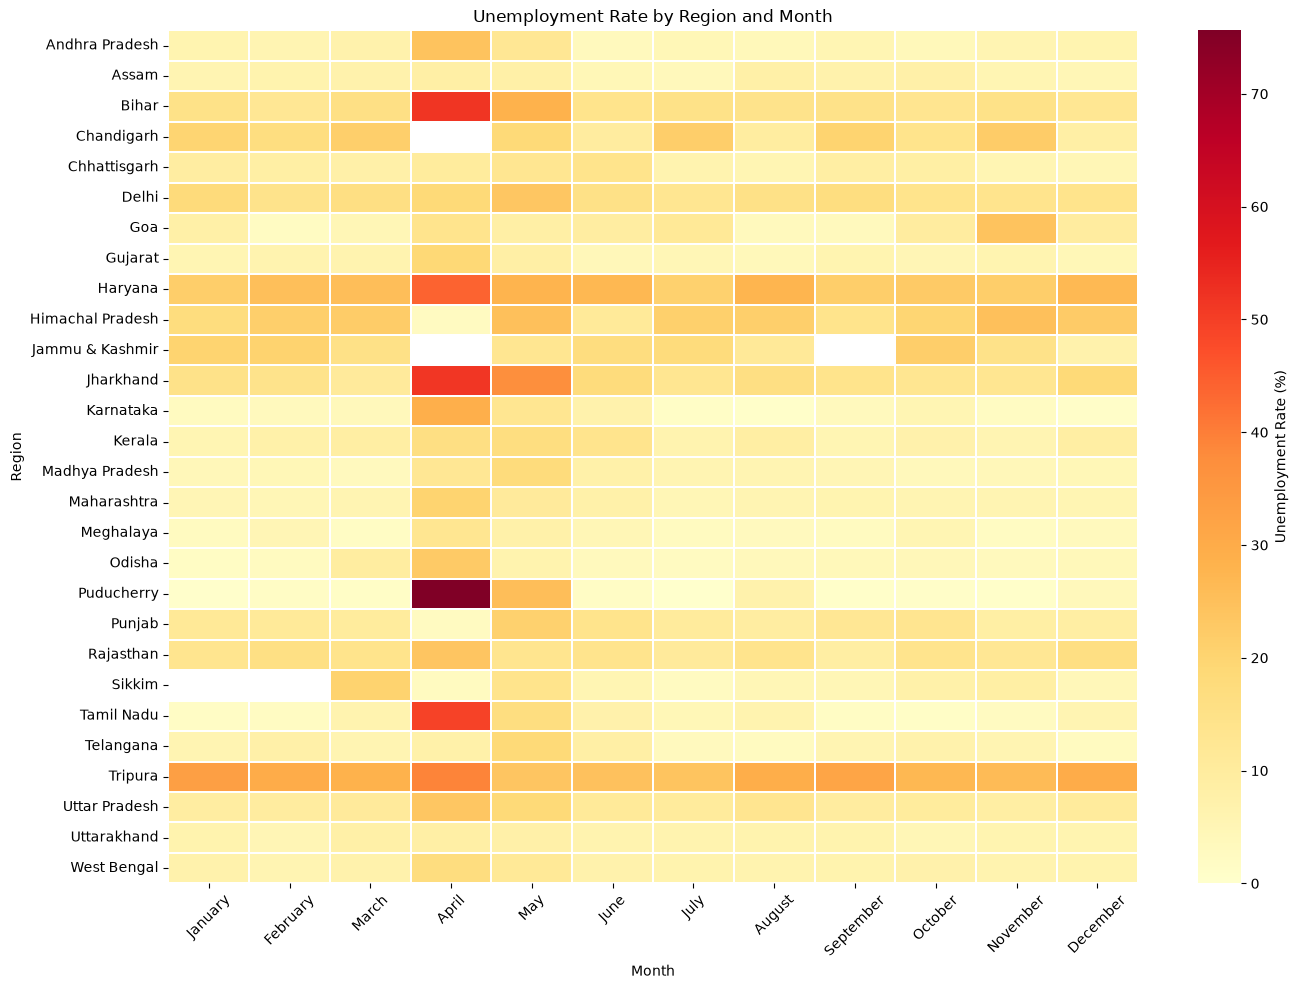

In [53]:
regional_seasonality = (
    df.groupby(['Region', 'Month', 'Month_Name'])['Estimated_Unemployment_Rate_(%)']
    .mean()
    .reset_index()
)

# Arrange the data into a grid: regions as rows, months as columns
heatmap_data = regional_seasonality.pivot(
    index='Region', columns='Month_Name', values='Estimated_Unemployment_Rate_(%)'
)

# Put months in calendar order (Jan to Dec)
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December']

heatmap_data = heatmap_data[[m for m in month_order if m in heatmap_data.columns]]

plt.figure(figsize=(14, 10))
sns.heatmap(
    heatmap_data,
    cmap='YlOrRd',
    linewidths=0.3,
    cbar_kws={'label': 'Unemployment Rate (%)'}
)

plt.title('Unemployment Rate by Region and Month')
plt.xlabel('Month')
plt.ylabel('Region')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../images/13_regional_seasonality_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### What the heatmap shows

Look for a bright vertical stripe around April/May — that's COVID, and it
should show up across almost every region, not just one or two. That tells us
the shock was nationwide, not limited to a few places (matches what we already
found in 04_covid_impact_analysis.ipynb).

Outside of that stripe, look for any region with noticeably darker or lighter
colors than the rest all year round — that would mean "this region just runs
higher or lower than everyone else," not a seasonal thing, just a general
level difference.

## Seasonal Trends Summary

### Can we prove a repeating yearly pattern?
No — and that's an honest, important finding on its own. We only have about
14 months of data. Almost every calendar month shows up just once. To prove a
real "season," you need to see the same month behave the same way across at
least 2-3 different years. We can't do that here.

### What we can honestly say
- Before COVID, the unemployment rate stayed fairly steady, roughly 9-10%,
  with small normal month-to-month movement — no big swings.
- The only large, sudden change we see is the COVID spike in April/May 2020,
  which is an outside shock, not a seasonal pattern.
- Looking region by region, the COVID spike shows up almost everywhere at
  the same time, meaning it was a nationwide shock, not something limited to
  a few places.

### Next step
Final notebook — pulling everything together (cleaning, EDA, COVID impact,
and this seasonal check) into clear insights and recommendations.